# Optimal Stock Portfolio Construction using Analytic Hierarchy Process (AHP) and Mean-Variance (MV) Methods

WRITER: DICKY RAMADHAN

This project demonstrates a robust approach to constructing an optimal stock portfolio by integrating two powerful quantitative methods: the Analytic Hierarchy Process (AHP) for initial stock selection based on financial ratios, and the Mean-Variance (MV) model for portfolio optimization. The study focuses on stocks listed in the SRI-KEHATI Index, known for their commitment to Environmental, Social, and Good Governance (ESG) principles.

**Project Goal:**
The primary objective of this project is to identify and construct an optimal stock portfolio that aims to maximize returns for a given level of risk, or minimize risk for a given level of return. This is achieved by first prioritizing stocks based on fundamental financial health using AHP, and then optimizing the allocation of capital among the top-ranked stocks using the Mean-Variance model.

**Why this approach?**
* **Analytic Hierarchy Process (AHP):** AHP provides a structured framework for decision-making involving multiple criteria. In this project, it's used to systematically evaluate and rank stocks based on key financial ratios (NPM, ROA, ROE, PBV, EPS, P/E, DER, DAR, DPR, DY). This method helps in making informed initial selections by considering various fundamental aspects of a company's performance.
* **Mean-Variance (MV) Model:** Developed by Harry Markowitz, the MV model is a cornerstone of modern portfolio theory. It helps in constructing diversified portfolios that offer the highest expected return for a given level of risk, or the lowest risk for a given expected return, by analyzing historical returns and covariances of assets.
* **SRI-KEHATI Index:** Focusing on the SRI-KEHATI Index ensures that the selected stocks adhere to sustainable and responsible investment principles, which is an increasingly important factor in modern investment strategies.

This project showcases skills in data analysis, financial modeling, optimization techniques, and Python programming for financial applications.

## 1. Import necessary libraries for data manipulation, financial analysis, and optimization.
- **pandas**: For data manipulation and analysis, especially with DataFrames.
- **numpy**: For numerical operations, crucial for array and matrix calculations in AHP and MV.
- **yfinance**: To download historical stock data from Yahoo Finance.
- **scipy.optimize**: For numerical optimization, specifically for finding optimal portfolio weights in the MV model.
- **matplotlib.pyplot**: For plotting and visualizing portfolio performance (e.g., Efficient Frontier).
- **seaborn**: For enhanced data visualizations.

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Data Loading
Load financial ratio data. This data contains key financial indicators for each stock in Index SRI-KEHATI that will be used as criteria in the Analytic Hierarchy Process (AHP) The financial ratios include: Net Profit Margin (NPM), Return on Assets (ROA), Return on Equity (ROE), Price to Book Value (PBV), Earning Per Share (EPS) Price to Earnings Ratio (P/E), Debt to Equity Ratio (DER), Debt to Asset Ratio (DAR),Dividend Payout Ratio (DPR), and Dividend Yield (DY). The data is sourced and calculated based on the Trailing Twelve Months (TTM) method.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Criteria
df_kriteria = pd.read_excel('/content/drive/My Drive/My CV/Portfolio/AHP-MV_to_StockPortfolio/NilaiKriteria.xlsx',
                            sheet_name='Kriteria', usecols='A:K', nrows=11,
                            header=None, index_col=False)
criteria_names = df_kriteria.iloc[1:, 0].tolist()
criteria_matrix = df_kriteria.iloc[1:, 1:].to_numpy(dtype=float)

# Alternative
df_alternatif = pd.read_excel('/content/drive/My Drive/My CV/Portfolio/AHP-MV_to_StockPortfolio/NilaiKriteria.xlsx',
                              sheet_name='Alternatif', usecols='A:K', nrows=26,
                              header=None, index_col=False)
alternatif_names = df_alternatif.iloc[1:, 0].tolist()
alternatif_matrix = df_alternatif.iloc[1:, 1:].to_numpy(dtype=float)

Mounted at /content/drive


## 3. Analytic Hierarchy Process (AHP) Implementation
AHP is a decision-making framework that allows for the structuring of complex decisions into a hierarchy of criteria and alternatives. It uses pairwise comparisons to determine the relative importance of criteria and the relative performance of alternatives against each criterion.

In [ ]:
# Analytic Hierarchy Process Method

def create_normalize_matrix(comparison_matrix):
    # Normalizes the pairwise comparison matrix by dividing each element by the sum of its column.
    # This step prepares the matrix for calculating the weights (priorities).
    return comparison_matrix / np.sum(np.abs(comparison_matrix), axis=0)

def calculated_weights(normalize_matrix):
    # Calculates the weights (priorities) of criteria or alternatives by averaging the rows of the normalized matrix.
    # These weights represent the relative importance or preference.
    return normalize_matrix.sum(axis=1)/normalize_matrix.shape[0]

# Consistency Ratio (CR)
def consistency_ratio(comparison_matrix, weights):
    # Calculates Lambda Max (λ_max), a measure used to check the consistency of the judgments.
    # It's the principal eigenvalue of the pairwise comparison matrix.
    lambda_max_vector = np.dot(comparison_matrix, weights)
    lambda_max = np.sum(lambda_max_vector)
    # Calculates the Consistency Index (CI), which measures the deviation of consistency from perfect consistency.
    n = comparison_matrix.shape[0]
    CI = (lambda_max - n) / (n - 1)
    # Table Random Index (RI)
    RI = [0, 0, 0.58, 0.9, 1.12, 1.24, 1.32, 1.41, 1.45, 1.49, 1.51, 1.48, 1.56, 1.57, 1.59]
    if n <= 15 :
        random_index = RI[n]
    else :
        random_index = 1.59
    # Calculates the Consistency Ratio (CR) by dividing the Consistency Index (CI) by the Random Index (RI).
    # A CR < 0.10 (or 10%) is generally considered acceptable, indicating a reasonable level of consistency in judgments.
    CR = CI / random_index
    return CR

# Creates a pairwise comparison matrix for AHP.
def create_and_round_consistent_matrix(data):
    # The matrix is filled based on subjective judgments or expert opinions regarding
    # the relative importance of each criterion. Saaty's scale (1-9) is used for comparisons.
    n = len(data)
    matrix = np.ones((n, n))
    for i in range(n):
        for j in range(i+1, n):
            comparison_value = data[i] / data[j]
            rounded_value = min(ahp_scale,
                                key=lambda x: abs(x-comparison_value))
            matrix[i][j] = rounded_value
            matrix[j][i] = 1 / rounded_value
    # Example (replace with your actual matrix values):
    # matrix[0, 1] = 3 # NPM vs ROA
    # matrix[1, 0] = 1/3 # ROA vs NPM
    # ... and so on for all pairwise comparisons
    return matrix

# Alternative Score
def calculate_alternative_scores(alternative_matrix, weights):
    return np.dot(alternative_matrix, weights)

### 3.1. AHP for Criteria (Financial Ratios)
This matrix reflects the relative importance of each financial ratio in stock selection. The criteria comparison matrix in this study was developed based on market conditions, expert opinions, and previous research on financial ratios. Essentially, the construction of this matrix is subjective and tailored to specific needs, as each investor has different preferences and considerations when evaluating financial ratios. The matrix uses the pairwise comparison scale introduced by Saaty in the 1970s, where each comparison between elements is represented by a value from 1 to 9, indicating the relative importance of one element over another. Based on this approach, the following criteria comparison matrix was obtained. Fineancial Ratios used in this study is NPM, ROA, ROE, PBV, EPS, P/E, DER, DAR, DPR, DY.


In [ ]:
# Comparison Criteria Matrix
print(pd.DataFrame(criteria_matrix))
# This matrix reflects the relative importance of each financial ratio in stock selection.

# Normalize matrix Criteria
normalize_criteria_matrix = create_normalize_matrix(criteria_matrix)
#print(pd.DataFrame(normalize_criteria_matrix))

# Calculated Criteria Weight
criteria_weights = calculated_weights(normalize_criteria_matrix)
#print(pd.DataFrame(criteria_weights))

# Consistency Ratio (CR) for Criteria
CR = consistency_ratio(criteria_matrix, criteria_weights)

print("\n--- AHP for Criteria (Financial Ratios) ---")
print("Criteria Weights:", criteria_weights)
print(f"Consistency Ratio (CR) for Criteria: {CR:.4f}")
if CR < 0.10:
    print("Consistency is acceptable (CR < 10%).")
else:
    print("Consistency is not acceptable (CR >= 10%). Re-evaluate pairwise comparisons.")

          0    1    2         3    4         5         6    7    8    9
0  1.000000  3.0  3.0  0.333333  3.0  1.000000  1.000000  5.0  3.0  3.0
1  0.333333  1.0  1.0  0.111111  1.0  0.333333  0.333333  2.0  1.0  1.0
2  0.333333  1.0  1.0  0.111111  1.0  0.333333  0.333333  2.0  1.0  1.0
3  3.000000  9.0  9.0  1.000000  9.0  3.000000  3.000000  9.0  9.0  9.0
4  0.333333  1.0  1.0  0.111111  1.0  0.333333  0.333333  2.0  1.0  1.0
5  1.000000  3.0  3.0  0.333333  3.0  1.000000  1.000000  5.0  3.0  3.0
6  1.000000  3.0  3.0  0.333333  3.0  1.000000  1.000000  5.0  3.0  3.0
7  0.200000  0.5  0.5  0.111111  0.5  0.200000  0.200000  1.0  0.5  0.5
8  0.333333  1.0  1.0  0.111111  1.0  0.333333  0.333333  2.0  1.0  1.0
9  0.333333  1.0  1.0  0.111111  1.0  0.333333  0.333333  2.0  1.0  1.0

--- AHP for Criteria (Financial Ratios) ---
Criteria Weights: [0.12875109 0.04386941 0.04386941 0.36911043 0.04386941 0.12875109
 0.12875109 0.02528923 0.04386941 0.04386941]
Consistency Ratio (CR) for Crite

### 3.2. AHP for Alternatives (Stocks) under Each Criterion
This process involves creating a pairwise comparison matrix for all 25 stocks
under each of the 10 financial ratio criteria. This part is highly dependent on how you generated the pairwise comparison matrices for each stock under each financial ratio. This project used indicates these were derived based on the actual financial ratio values of the stocks.

In [ ]:
# AHP Comparison Scale
ahp_scale = [1/9, 1/8, 1/7, 1/6, 1/5, 1/4, 1/3, 1/2, 1, 2, 3, 4, 5, 6, 7, 8, 9]

# Inisialisasation Weight Matrix
weights_matrix = np.zeros((len(alternatif_matrix), len(alternatif_matrix[0])))

# Alternatve Weight on every Criteria
for i in range(len(alternatif_matrix[0])):
    data = []
    for j in range(len(alternatif_matrix)):
        data.append(alternatif_matrix[j][i])
    matrix = create_and_round_consistent_matrix(data)
    #print(f"{criteria_names[i]}:")
    #print(pd.DataFrame(matrix))

    # Normalization matrix
    normalize_matrix = create_normalize_matrix(matrix)

    # Clculated Weight
    alternatif_weights = calculated_weights(normalize_matrix)

    # Consistency Ratio
    CR = consistency_ratio(matrix, alternatif_weights)

    # Colect weight in the matrix
    weights_matrix[:, i] = alternatif_weights

    print("Alternative Weights:", alternatif_weights)
    print(f"Consistency Ratio (CR) for {criteria_names[i]}: {CR:.4f}")
    if CR < 0.10:
        print("Consistency is acceptable (CR < 10%).")
    else:
        print("Consistency is not acceptable (CR >= 10%). Re-evaluate pairwise comparisons.")

Alternative Weights: [0.02742307 0.0222718  0.04400594 0.05988022 0.05205987 0.05205987
 0.0222718  0.05926483 0.04629348 0.04629348 0.03190534 0.0475056
 0.0475056  0.03950057 0.03379511 0.02352302 0.06735205 0.05357503
 0.05008856 0.01671043 0.03574956 0.00764476 0.05423076 0.05144449
 0.00764476]
Consistency Ratio (CR) for NPM: 0.0095
Consistency is acceptable (CR < 10%).
Alternative Weights: [0.0361539  0.0361539  0.06296262 0.0536666  0.03009098 0.0536666
 0.01507632 0.03893703 0.0227308  0.04494572 0.01577852 0.03957195
 0.05791881 0.0318662  0.04619572 0.04619572 0.05791881 0.0682573
 0.0682573  0.02399072 0.041886   0.00776523 0.0682573  0.02399072
 0.00776523]
Consistency Ratio (CR) for ROA: 0.0094
Consistency is acceptable (CR < 10%).
Alternative Weights: [0.02065756 0.03246496 0.03389115 0.05034923 0.04187541 0.05034923
 0.03587932 0.05175768 0.06571238 0.03327577 0.01502419 0.03749575
 0.03749575 0.03749575 0.03749575 0.03749575 0.06571238 0.03749575
 0.03749575 0.03327577 

### 3.3. Calculate Overall AHP Scores for Stocks
This is the final step of the AHP analysis. The code calculates the overall priority scores for each stock by performing a matrix multiplication between the weights of the alternatives and the weights of the criteria. The resulting scores are then used to rank the stocks. The top 5 stocks from this ranking are selected for the next stage: portfolio optimization.


In [ ]:
# Calculating scores for each alternative
alternatif_scores = calculate_alternative_scores(weights_matrix,
                                                 criteria_weights)

# Creating a dictionary to store alternative names and their scores
alternatif_dict = {name: score for name, score in zip(alternatif_names,
                                                      alternatif_scores)}

# Sorting alternatives based on their scores
sorted_alternatif = sorted(alternatif_dict.items(), key=lambda item: item[1],
                           reverse=True)

# Print Alternative Rank
print("Alternative Rank base on AHP:")
for rank, (name, score) in enumerate(sorted_alternatif, start=1):
    print(f"{rank}. {name} : {score}")

Alternative Rank base on AHP:
1. INCO : 0.049450974462928975
2. AUTO : 0.04938931158846047
3. JSMR : 0.047204737293991834
4. BBNI : 0.04680859915678363
5. BMRI : 0.046190228399097484
6. INDF : 0.04605491778673364
7. DSNG : 0.04464466724660891
8. AALI : 0.04464367915349914
9. TLKM : 0.04439510421607459
10. ANTM : 0.044075479887719045
11. INTP : 0.043887636619592205
12. BBTN : 0.04299293790832036
13. BBRI : 0.04220729476405557
14. KLBF : 0.04180498822095813
15. SMGR : 0.04176011225680144
16. DRMA : 0.040287917941664544
17. EMTK : 0.03980612396084219
18. JPFA : 0.03849219225577335
19. SILO : 0.03348256700542075
20. ICBP : 0.0321779221712831
21. TINS : 0.031678625606007975
22. BBCA : 0.02960274844607054
23. SSMS : 0.02868240432584209
24. UNVR : 0.02577206685809757
25. WIKA : 0.024506762467372382


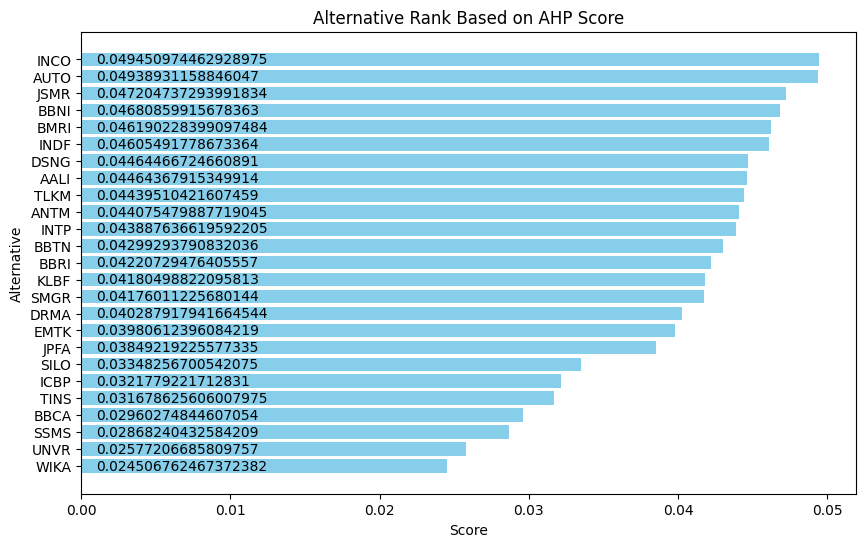

In [ ]:
# Vizulaisation for Alternative Rank
names = [item[0] for item in sorted_alternatif]
scores = [item[1] for item in sorted_alternatif]

plt.figure(figsize=(10, 6))
plt.barh(names, scores, color='skyblue')
plt.xlabel('Score')
plt.ylabel('Alternative')
plt.title('Alternative Rank Based on AHP Score')
for i, score in enumerate(scores):
  plt.text(0.001, i, f'{score}', va='center', ha='left', color='black')
plt.gca().invert_yaxis()
plt.show()


## 4. Mean-Variance (MV) Optimization

The Mean-Variance model, developed by Harry Markowitz, is used to construct an optimal portfolio by considering the trade-off between expected portfolio return and portfolio risk (volatility).  The goal is to find the asset allocation (weights) that either maximizes return for a given risk or minimizes risk for a given return, typically by maximizing the Sharpe Ratio. This section fetches historical data for the top 5 AHP-ranked stocks, calculates their returns, covariance matrix, and then uses optimization to find the portfolio weights that maximize the Sharpe Ratio.

### Optimization Function (optimize_portfolio):

Inputs: Expected returns, covariance matrix of the stocks, and the risk-free rate.

Objective: The function aims to find the portfolio weights that maximize the Sharpe Ratio. This is achieved by minimizing the negative Sharpe Ratio.

Constraints:
The sum of all weights must equal 1 (100%).
All weights must be non-negative (no short selling).

Solver: The SLSQP (Sequential Least Squares Programming) method is used to solve this constrained optimization problem.

In [ ]:
# Mean-Variance Method

def calculate_sharpe_ratio(weights, mean_returns, cov_matrix, risk_free_rate):
    # Function to calculate the Sharpe ratio of a portfolio
    port_return = np.sum(mean_returns * weights) * 252
    port_stddev = np.sqrt(np.dot(weights.T,
                                 np.dot(cov_matrix, weights))) * np.sqrt(252)
    sharpe_ratio = (port_return - risk_free_rate) / port_stddev
    return -sharpe_ratio # Negative because we want to maximize the Sharpe ratio

def get_optimal_weights(mean_returns, cov_matrix, risk_free_rate):
    # Function to obtain optimal asset weights
    num_assets = len(mean_returns)
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1}) # Set constraints: weights must sum to 1.
    bounds = tuple((0, 1) for asset in range(num_assets)) # Set bounds: weights must be between 0 and 1 (no short selling).
    result = minimize(calculate_sharpe_ratio, num_assets*[1./num_assets,], # Initial guess for weights (equal distribution).
                      args=(mean_returns, cov_matrix, risk_free_rate),
                      method='SLSQP', bounds=bounds, constraints=constraints)# Use the SLSQP optimizer to find the optimal weights.
    return result.x

def assign_tickers_to_weights(tickers, optimal_weights):
    # Create a dictionary to map ticker names to their optimal weights
    ticker_weights = {ticker: weight for ticker,
                      weight in zip(tickers, optimal_weights)}
    return ticker_weights

### 4.1. Data Fetching

Historical daily closing prices for the top 5 stocks are downloaded from Yahoo Finance for a one-year period.
Daily returns are calculated from these prices.

In [ ]:
# Fetch historical daily closing prices for the top 5 AHP-ranked stocks.

# Define the ticker symbols for Yahoo Finance (appending '.JK' for Indonesian stocks).
tickers = [name + '.JK' for name, score in sorted_alternatif[:5]]

# Set the time period for historical data analysis.
start_date = '2023-04-01'
end_date = '2024-03-31'

# Download historical closing prices from Yahoo Finance.
returns = yf.download(tickers, start=start_date,
                      end=end_date)['Close'].pct_change()
print(returns.head())

/tmp/ipython-input-9-3253496141.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  returns = yf.download(tickers, start=start_date,
[*********************100%***********************]  5 of 5 completed

Ticker       AUTO.JK   BBNI.JK   BMRI.JK   INCO.JK   JSMR.JK
Date                                                        
2023-04-03       NaN       NaN       NaN       NaN       NaN
2023-04-04  0.000000  0.000000 -0.011876 -0.003690  0.003049
2023-04-05 -0.056716 -0.002674  0.004808 -0.014815  0.012158
2023-04-06  0.006329  0.005362 -0.009569 -0.037594  0.015015
2023-04-10  0.009434 -0.005333 -0.014493  0.000000  0.008876


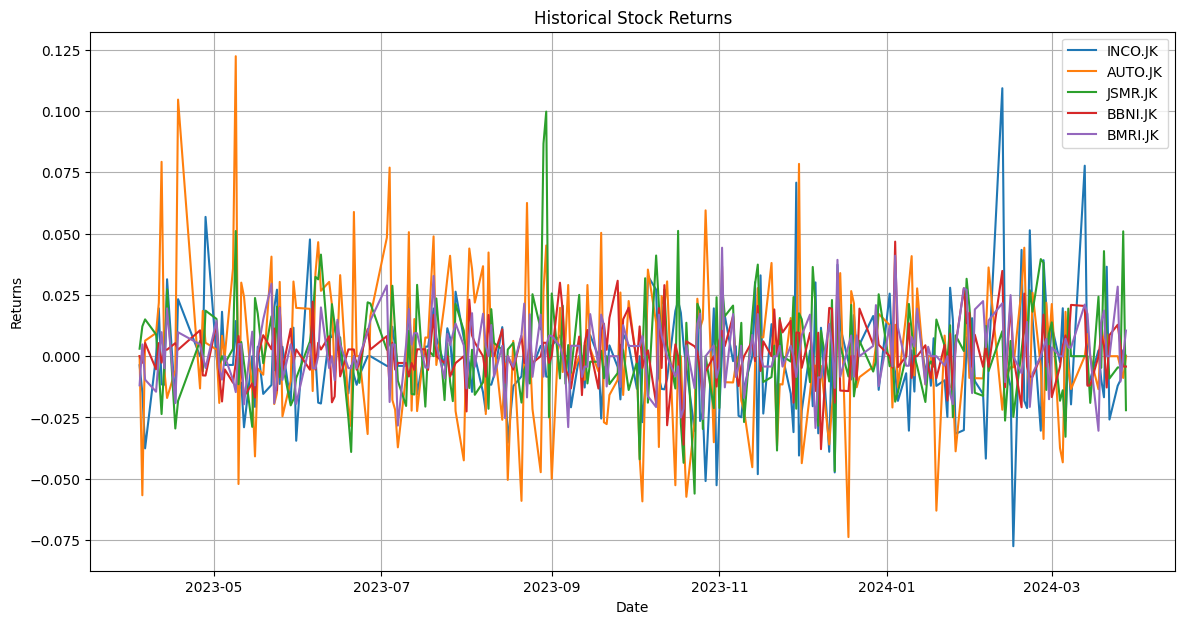

In [ ]:
# Retrieve historical stock return data (for verification purposes only)
plt.figure(figsize=(14, 7))
for ticker in tickers:
    plt.plot(returns.index, returns[ticker], label=ticker)

plt.title('Historical Stock Returns')
plt.xlabel('Date')
plt.ylabel('Returns')
plt.legend()
plt.grid(True)
plt.show()

/tmp/ipython-input-11-1210685708.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(tickers, start=start_date, end=end_date)['Close']
[*********************100%***********************]  5 of 5 completed


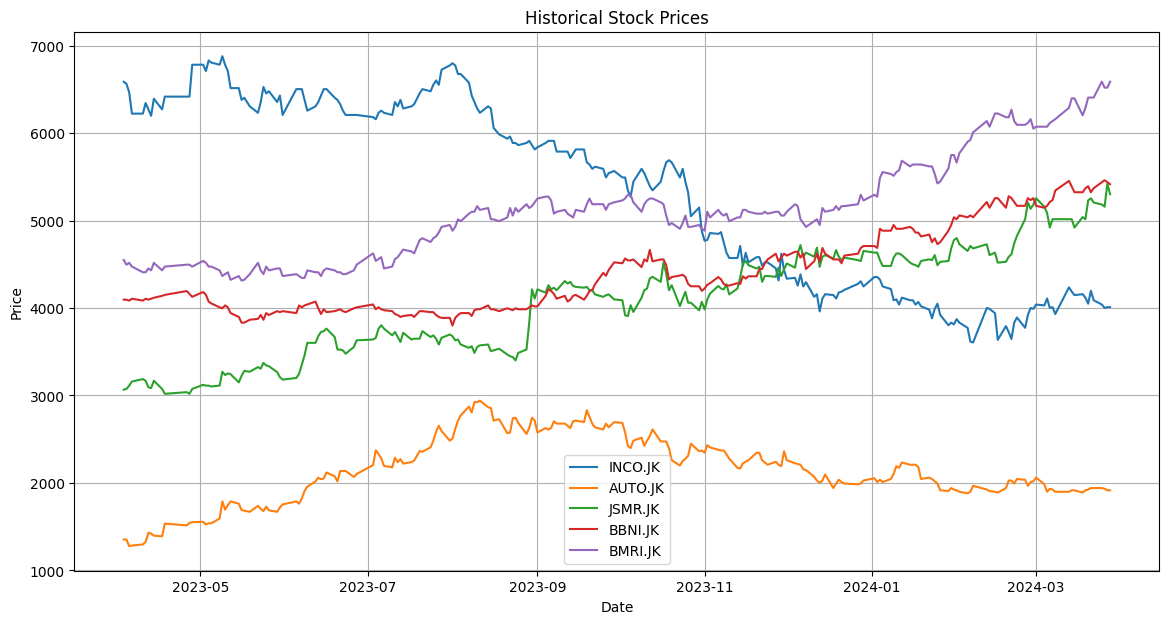

In [ ]:
# Retrieve historical stock price data (for verification purposes only)
prices = yf.download(tickers, start=start_date, end=end_date)['Close']

plt.figure(figsize=(14, 7))
for ticker in tickers:
    plt.plot(prices.index, prices[ticker], label=ticker)
plt.title('Historical Stock Prices')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

### 4.2. Executing the Optimization and Displaying Results
This block runs the optimization process and presents the final results.

**Inputs for Optimization**:

- expected_returns: The annualized average daily returns.
- cov_matrix: The annualized covariance of returns.
- risk_free_rate: The BI 7-Day Reverse Repo Rate is used as a proxy for the risk-free rate in Indonesia.

**Optimal Weights**: The optimize_portfolio function is called to calculate the ideal allocation for each stock.

**Portfolio Performance**: Key metrics like the expected annual return, volatility (risk), and the Sharpe Ratio are calculated for the final optimal portfolio and displayed.

In [ ]:
# Calculate mean returns and kovariantion matrix
mean_returns = returns.mean()
print(f"Rata-rata Pengembalian: {mean_returns}")
cov_matrix = returns.cov()
print(pd.DataFrame(cov_matrix))
tickers = mean_returns.sort_index().index.tolist()

# Run the optimization to get the optimal portfolio weights.
risk_free_rate = 0.05875 ## Set the risk-free rate (e.g., BI 7-Day Reverse Repo Rate).
optimal_weights = get_optimal_weights(mean_returns, cov_matrix, risk_free_rate)
print(optimal_weights)

# Simulation portfolio
num_portfolios = 50000
results = np.zeros((4 , num_portfolios))

for i in range(num_portfolios):
    weights = np.random.random(len(tickers))
    weights /= np.sum(weights)
    port_return = np.sum(mean_returns * weights) * 252 # 252 = 1 years
    port_stddev = np.sqrt(np.dot(weights.T,
                                 np.dot(cov_matrix, weights))) * np.sqrt(252)
    port_sharpe = (port_return - risk_free_rate) / port_stddev
    results[0,i] = port_return
    results[1,i] = port_stddev
    results[2,i] = port_sharpe
port_returns, port_vols, sharpe_ratios, port_weights = results

# Calculate the performance metrics of the optimal portfolio.
optimal_sharpe = -calculate_sharpe_ratio(optimal_weights, mean_returns,
                                         cov_matrix, risk_free_rate)
optimal_return = np.sum(mean_returns * optimal_weights) * 252
optimal_volatility = np.sqrt(
    np.dot(optimal_weights.T,
           np.dot(cov_matrix, optimal_weights))) * np.sqrt(252)

Rata-rata Pengembalian: Ticker
AUTO.JK    0.001900
BBNI.JK    0.001267
BMRI.JK    0.001666
INCO.JK   -0.001891
JSMR.JK    0.002552
dtype: float64
Ticker    AUTO.JK   BBNI.JK   BMRI.JK   INCO.JK   JSMR.JK
Ticker                                                   
AUTO.JK  0.000837 -0.000003  0.000022  0.000012  0.000077
BBNI.JK -0.000003  0.000147  0.000071  0.000007  0.000019
BMRI.JK  0.000022  0.000071  0.000167  0.000002  0.000030
INCO.JK  0.000012  0.000007  0.000002  0.000462  0.000049
JSMR.JK  0.000077  0.000019  0.000030  0.000049  0.000424
[9.04322584e-02 2.27784577e-01 3.86340600e-01 1.59903557e-15
 2.95442564e-01]


### 4.3. Visualizing the Efficient Frontier
This final section generates a plot of the Efficient Frontier, a core concept in Modern Portfolio Theory.

**Monte Carlo Simulation**: A large number of random portfolio weights are generated to simulate thousands of possible portfolios.

**Efficient Frontier Plot**:
- The x-axis represents the portfolio's volatility (risk), and the y-axis represents its expected return.
- Each blue/green dot is a random portfolio. The color scale represents the Sharpe Ratio, with brighter colors indicating better risk-adjusted returns.
- The red star marks the location of the Optimal Portfolio—the single portfolio with the highest possible Sharpe Ratio, which lies on the "edge" of the frontier.

**Purpose**: This visualization effectively demonstrates that the calculated optimal portfolio is not just a random combination but is indeed the most efficient one among countless possibilities, providing the highest return for a given level of risk.

Optimal Portfolio
Weight AUTO.JK: 9.043226%
Weight BBNI.JK: 22.778458%
Weight BMRI.JK: 38.634060%
Weight INCO.JK: 0.000000%
Weight JSMR.JK: 29.544256%
Return = 0.468312, Volatility = 0.161695
Sharpe Ratio = 2.532921220898384


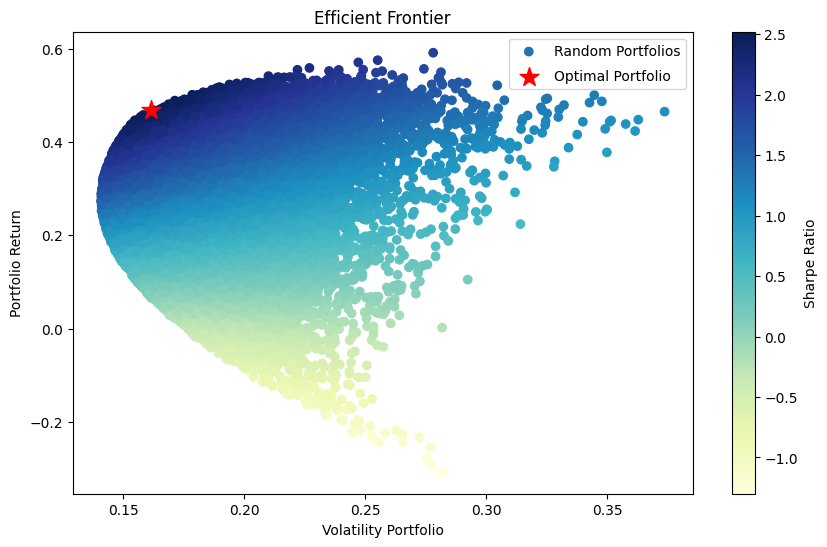

In [ ]:
# Optimal Portfolio
print("Optimal Portfolio")
for ticker, weight in zip(tickers, optimal_weights):
    print(f"Weight {ticker}: {weight:%}")
print(f"Return = {optimal_return:.6}, Volatility = {optimal_volatility:.6}")
print(f"Sharpe Ratio = {optimal_sharpe}")

# Plot efficient frontier
plt.figure(figsize=(10, 6))
plt.scatter(port_vols, port_returns, c=sharpe_ratios, cmap='YlGnBu',
            marker='o', label='Random Portfolios')
plt.colorbar(label='Sharpe Ratio')
plt.scatter(optimal_volatility, optimal_return, color='r', marker='*',
            s=200, label='Optimal Portfolio')
plt.title('Efficient Frontier')
plt.xlabel('Volatility Portfolio')
plt.ylabel('Portfolio Return')
plt.legend(labelspacing=0.8)
plt.show()

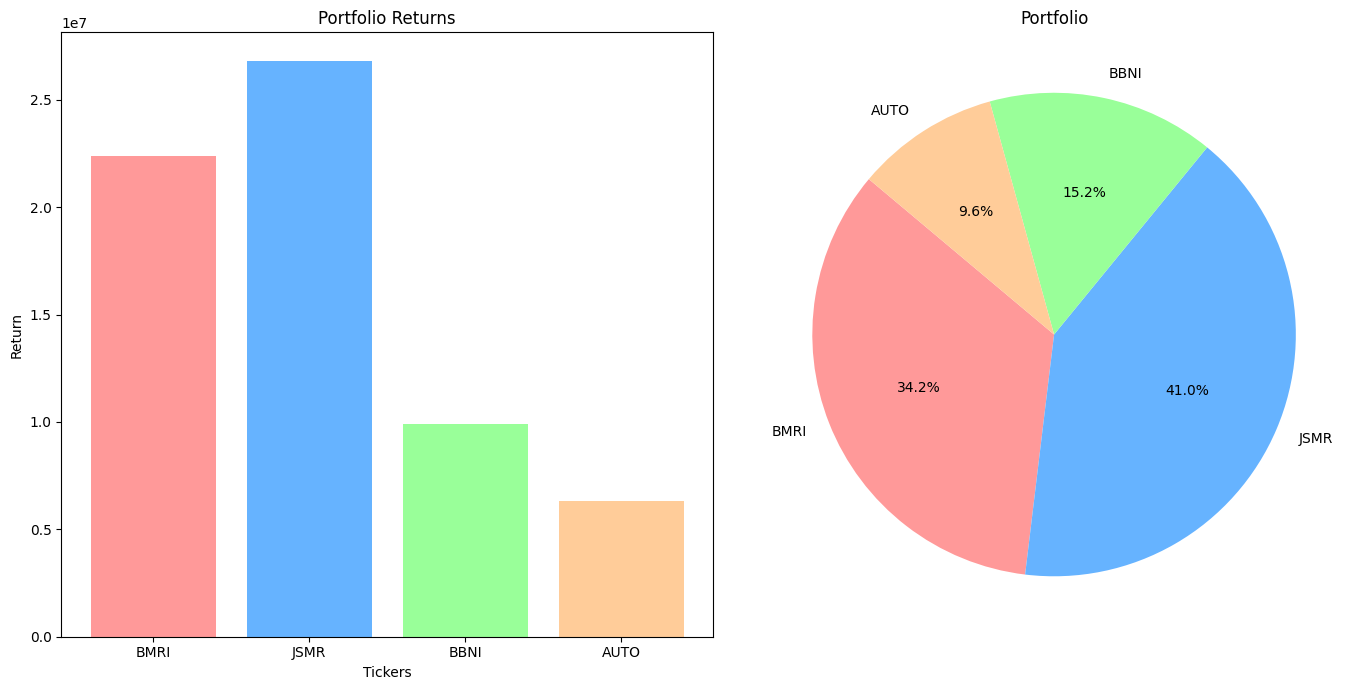

In [ ]:
# Data for bar chart
companies = ['BMRI', 'JSMR', 'BBNI', 'AUTO']
values = [22372560, 26797800, 9911160, 6300000]

# Data for pie chart
portfolio_weights = [34.2, 41, 15.2, 9.6]
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99']
fig, ax = plt.subplots(1, 2, figsize=(14, 7))

# Bar chart
ax[0].bar(companies, values, color=colors)
ax[0].set_title('Portfolio Returns')
ax[0].set_ylabel('Return')
ax[0].set_xlabel('Tickers')

# Pie chart
ax[1].pie(portfolio_weights, labels=companies, autopct='%1.1f%%',
          startangle=140, colors=colors)
ax[1].set_title('Portfolio')

# Adjust layout to fit both charts
plt.tight_layout()
plt.show()

## 5. Result
Based on the research findings, the following specific conclusions can be drawn:

The formation of a stock portfolio from the SRI-KEHATI Index by combining the AHP and MV methods is proven to yield very good results.
- The AHP method successfully established a stock ranking, with the top five stocks being INCO, AUTO, JSMR, BBNI, and BBRI. The bottom five stocks were WIKA, UNVR, SSMS, BBCA, and TINS.
- The optimal portfolio formed from the five best-ranked stocks resulted in the following weight allocation: BMRI 38.6%, JSMR 29.5%, BBNI 22.8%, AUTO 9%, and INCO 0%.
- The resulting portfolio's performance was excellent, showing an expected return of 0.468 and a volatility of 0.162. The achieved Sharpe Ratio was 2.533.

- A key advantage of this methodology is that the AHP model considers dividends as part of its assessment criteria. This makes the portfolio's total return more optimal and not solely dependent on stock price movements. This, in turn, reduces the risk of loss from share price declines.